<div style="background: linear-gradient(135deg, #4C1D95 0%, #F5F3FF 100%); padding: 24px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Classroom Analysis</h1>
    <div style="background: rgba(255, 255, 255, 0.2); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Goal:</strong> Find trends in data set 3
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs3.pkl')

df = all_dfs['df']
clean_df = all_dfs['clean_df']
clean_df2 = all_dfs['clean_df2']
clean_df3 = all_dfs['clean_df3']

In [2]:
print(clean_df3.columns.tolist())

['Project_1_Pct', 'Project_2_Pct', 'Project_3_Pct', 'Project_4_Pct', 'Project_5_Pct', 'Participation_1_Pct', 'Participation_2_Pct', 'Participation_3_Pct', 'Participation_4_Pct', 'Participation_5_Pct', 'Participation_6_Pct', 'Final_Grade_Pct']


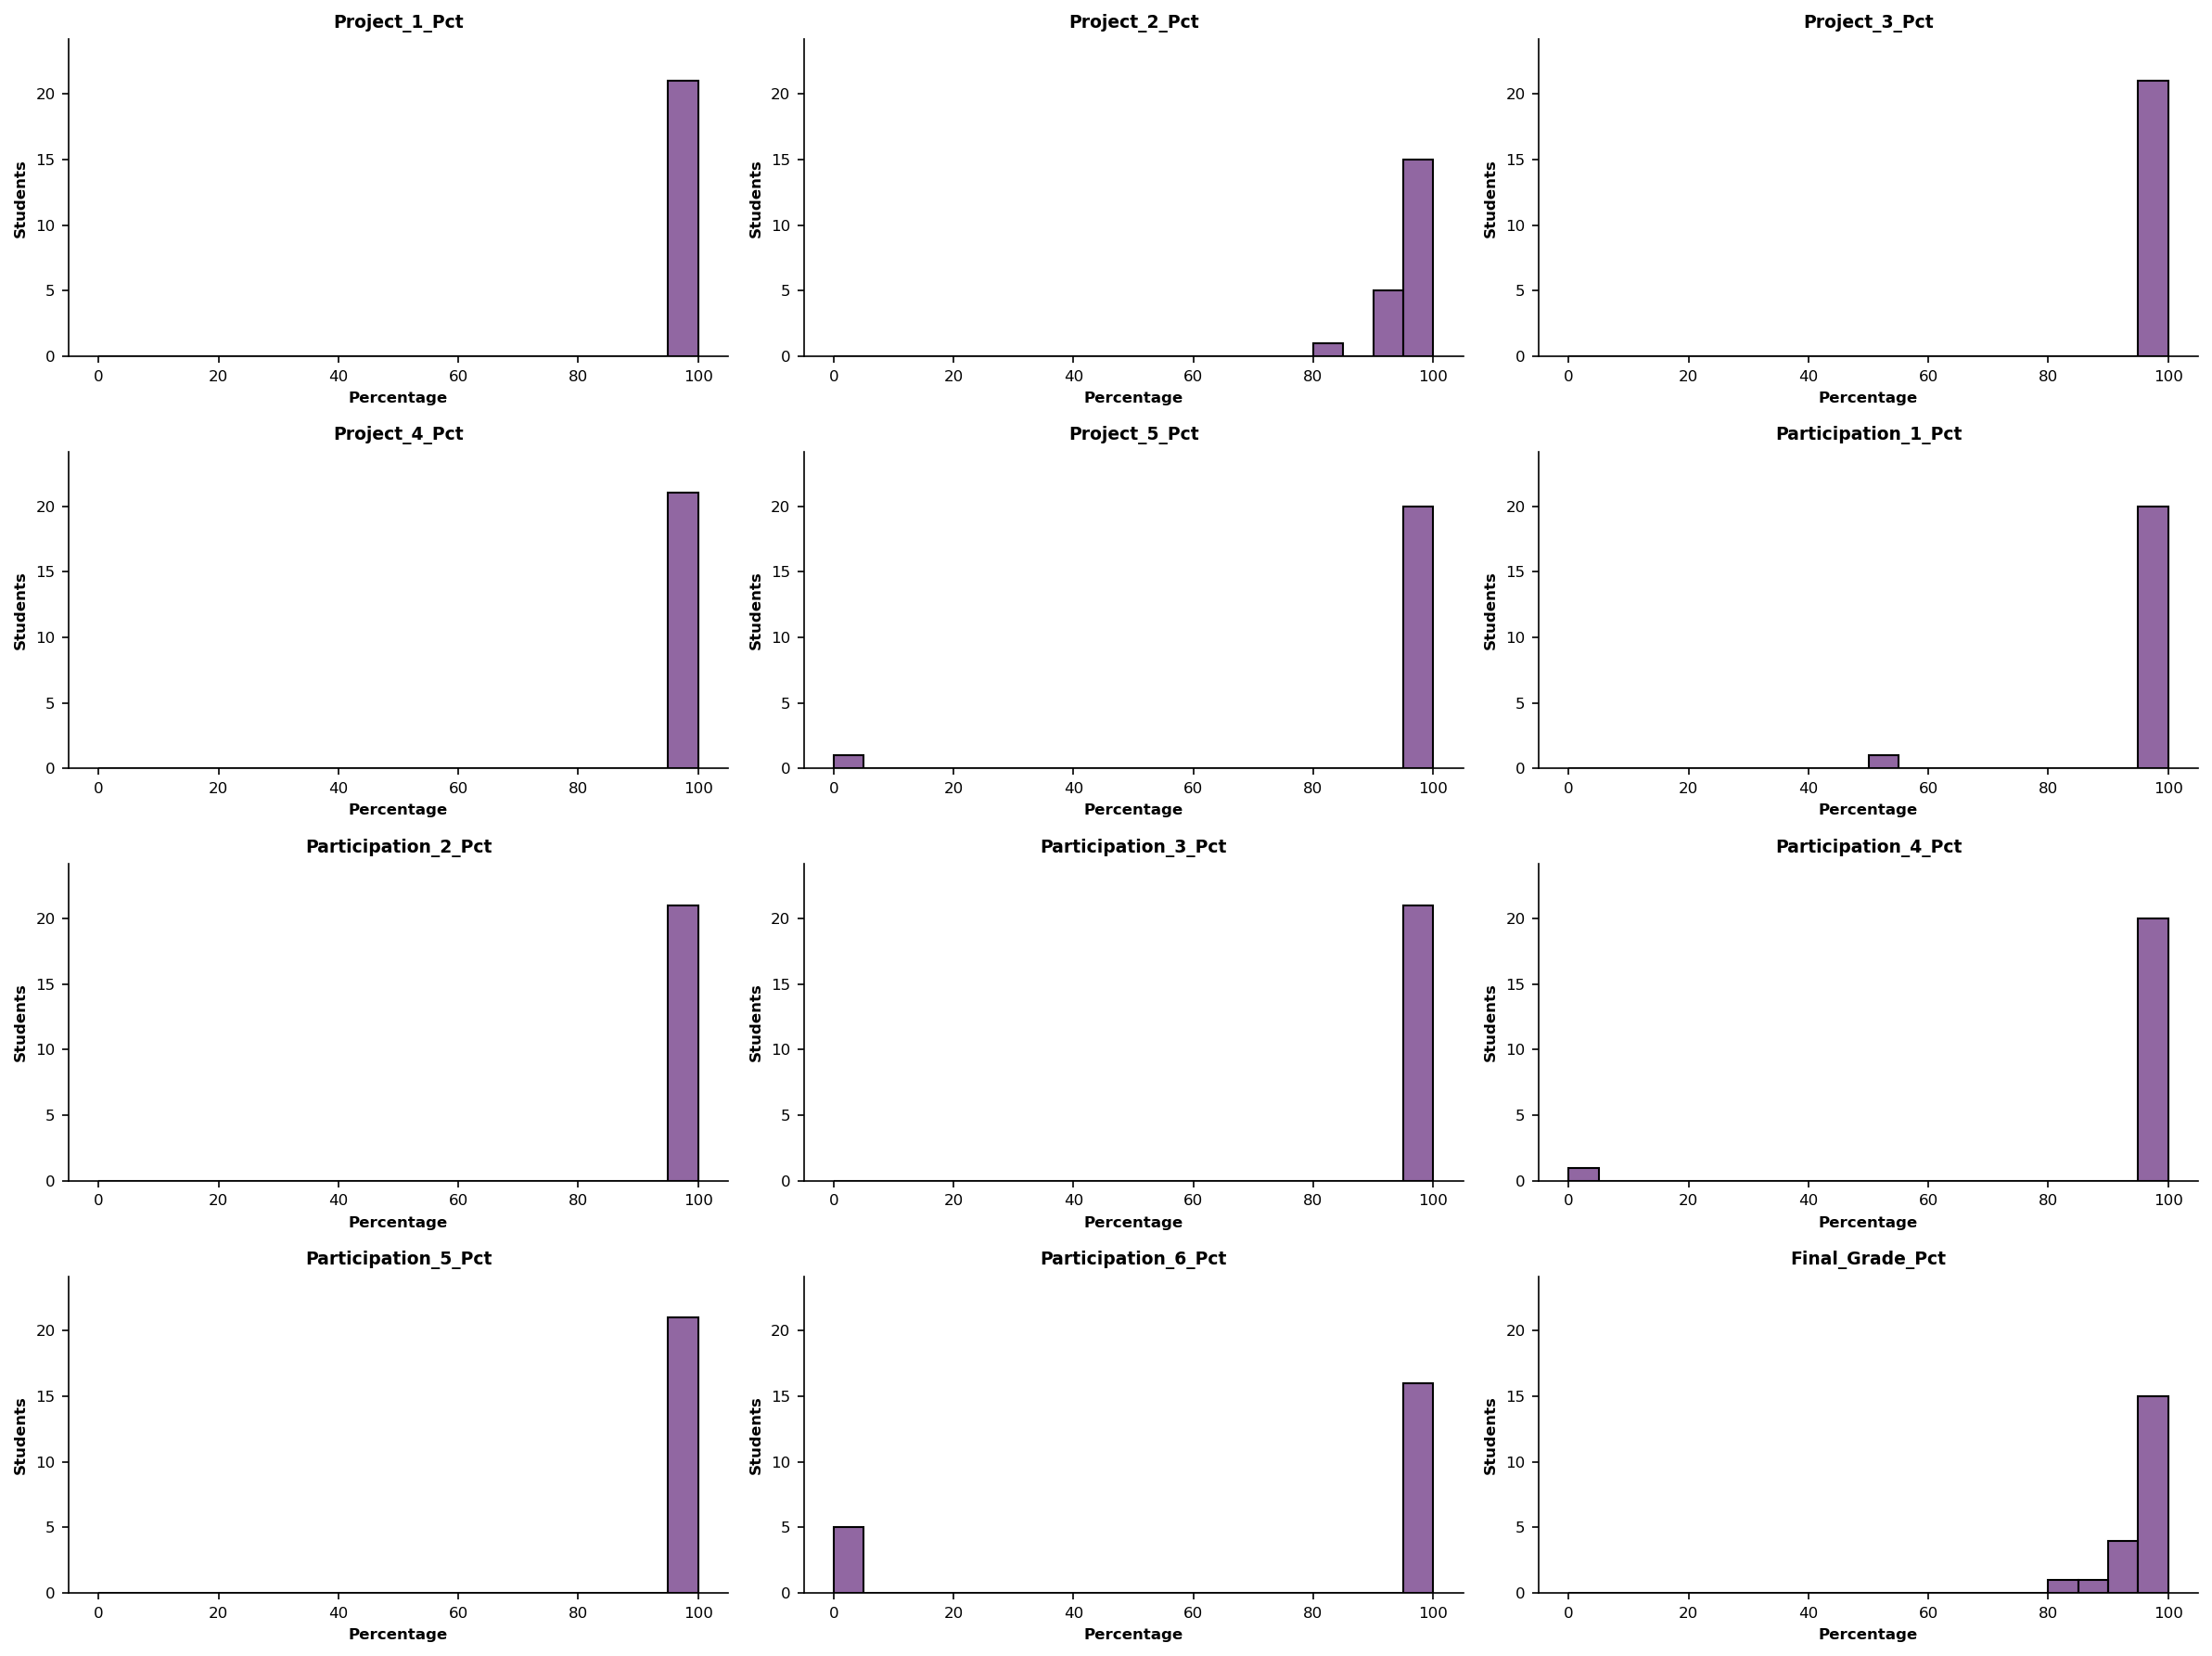

In [3]:
#Bar chart - counts

cols_to_plot = [
    'Project_1_Pct', 'Project_2_Pct', 'Project_3_Pct',  
    'Project_4_Pct', 'Project_5_Pct', 'Participation_1_Pct',  
    'Participation_2_Pct', 'Participation_3_Pct', 'Participation_4_Pct',  
    'Participation_5_Pct', 'Participation_6_Pct', 'Final_Grade_Pct'
]

valid_cols = [col for col in cols_to_plot if col in clean_df3.columns]
n_cols = len(valid_cols)

if n_cols > 0:
    ncols_grid = 3
    nrows_grid = (n_cols + ncols_grid - 1) // ncols_grid

    # grid layout
    fig, axes = plt.subplots(
        nrows_grid, ncols_grid, figsize=(16, 3 * nrows_grid), dpi=150
    )
    axes = axes.flatten()

    # Loop through columns
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        temp_df = clean_df3.copy()
        
        # Plot distribution
        sns.histplot(
            data=temp_df,
            x=col,
            color='#6c3483',
            ax=ax,
            kde=False,
            binwidth=5,
            binrange=(0, 100)
        )
        
        # Formatting
        sns.despine(ax=ax, top=True, right=True)
        ax.set_title(col, fontsize=9, fontweight='bold', pad=6)
        ax.set_xlabel('Percentage', fontsize=8, fontweight='bold')
        ax.set_ylabel('Students', fontsize=8, fontweight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.set_ylim(0, clean_df3.shape[0] * 1.15)
        ax.set_xlim(-5, 105)        # Keeps the x-axis consistently framed from 0 to 100

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [4]:
#Identify students struggling with projects but good in discussions, and vice versa
#due to privacy, student names not shown - cross reference against original file using index number


proj_cols = [col for col in clean_df3.columns if 'Project' in col and '_Pct' in col]
part_cols = [col for col in clean_df3.columns if ('Participation' in col or 'Discussion' in col) and '_Pct' in col]

# category averages for each student
clean_df3['Project_Composite'] = clean_df3[proj_cols].mean(axis=1)
clean_df3['Participation_Composite'] = clean_df3[part_cols].mean(axis=1)

# Calculate the difference
clean_df3['Performance_Gap'] = clean_df3['Project_Composite'] - clean_df3['Participation_Composite']

# find students who excel at projects but struggle w/ discussions
strong_projects = clean_df3.sort_values(by='Performance_Gap', ascending=False).head(5)

# find students who excel at discussions but struggle w/ projects
strong_discussions = clean_df3.sort_values(by='Performance_Gap', ascending=True).head(5)

print("--- Stronger in Projects / Struggling with Discussions ---")
print(strong_projects[['Project_Composite', 'Participation_Composite', 'Performance_Gap']])

print("\n--- Stronger in Discussions / Struggling with Projects ---")
print(strong_discussions[['Project_Composite', 'Participation_Composite', 'Performance_Gap']])

--- Stronger in Projects / Struggling with Discussions ---
    Project_Composite  Participation_Composite  Performance_Gap
5               100.0                83.333333        16.666667
18              100.0                83.333333        16.666667
20              100.0                83.333333        16.666667
10              100.0                83.333333        16.666667
14               98.0                83.333333        14.666667

--- Stronger in Discussions / Struggling with Projects ---
   Project_Composite  Participation_Composite  Performance_Gap
2               96.0               100.000000        -4.000000
4               80.0                83.333333        -3.333333
3               98.0               100.000000        -2.000000
8               98.0               100.000000        -2.000000
7               98.0               100.000000        -2.000000


In [6]:
from IPython.display import HTML, display

html_content = """
<div style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); padding: 22px 26px; border-radius: 10px; margin-bottom: 20px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h3 style="margin: 0 0 8px 0; color: #FFFFFF; font-size: 19px; font-weight: 700; border-bottom: none; padding: 0;">Data Set 3 Conclusions</h3>
    <div style="font-size: 14px; color: #E9D5FF; line-height: 1.6; font-weight: 400;">Because the grades in this dataset operate on a 1–4 scale and skew heavily toward high scores, combined with a limited student sample, approaches like category impact regressions, distribution skews, or missing work patterns lacked sufficient variance to generate meaningful insights. I did, however, uncover actionable insights for student support by analyzing cross-assessment gaps by identifying learners who excelled in discussions but struggled with projects, and vice versa. </div>
</div>
"""

display(HTML(html_content))